# Gas-CCS ATB 2024 — Envelope multipliers (moderate × multiplier)

Loads **advanced / moderate / conservative** from ReEDS GitHub raw links, then for each metric:
- fits least-squares multipliers mapping `moderate → advanced` and `moderate → conservative` over years ≥ `START_YEAR`
- builds an envelope: `moderate × [low_mult, high_mult]`
- plots with envelope shading **starting at START_YEAR**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---------------------------
# CONFIG
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas-ccs_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas-ccs_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas-ccs_ATB_2024_conservative.csv",
}

# If file contains multiple technologies in column `i`, set this.
# Otherwise leave None to auto-detect (if exactly one unique value).
TECH_FILTER = None  # e.g., "gas-CCS_mod"

METRICS = ["capcost", "fom", "vom", "heatrate"]

START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "gas_ccs_envelope_multipliers.csv"

In [3]:
def load_from_urls(urls: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(url)
        df["scenario"] = scen
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)

    out["t"] = pd.to_numeric(out["t"], errors="coerce")
    out = out.dropna(subset=["t"]).copy()
    out["t"] = out["t"].astype(int)

    # Auto-detect a single tech if TECH_FILTER is None
    global TECH_FILTER
    if "i" in out.columns and TECH_FILTER is None:
        techs = out.loc[out["scenario"] == "moderate", "i"].dropna().unique().tolist()
        if len(techs) == 1:
            TECH_FILTER = techs[0]

    if "i" in out.columns and TECH_FILTER is not None:
        out = out[out["i"] == TECH_FILTER].copy()

    return out.sort_values(["scenario", "t"]).reset_index(drop=True)

df = load_from_urls(FILE_URLS)
print("Rows:", len(df))
if "i" in df.columns:
    print("TECH_FILTER:", TECH_FILTER)
    print("Unique i:", df["i"].unique())
df.head()

Rows: 123
TECH_FILTER: Gas-CC-CCS_mod
Unique i: ['Gas-CC-CCS_mod']


,i,t,capcost,fom,vom,heatrate,scenario
0,Gas-CC-CCS_mod,2010,2572.02,68.796,5.0004,7.22,advanced
1,Gas-CC-CCS_mod,2011,2572.02,68.796,5.0004,7.22,advanced
2,Gas-CC-CCS_mod,2012,2572.02,68.796,5.0004,7.22,advanced
3,Gas-CC-CCS_mod,2013,2572.02,68.796,5.0004,7.22,advanced
4,Gas-CC-CCS_mod,2014,2572.02,68.796,5.0004,7.22,advanced


In [4]:
def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers(df: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for metric='{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope(df: pd.DataFrame, metric: str, start_year: int = 2025):
    info = envelope_multipliers(df, metric, start_year=start_year)

    piv = (df[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    # envelope starts at start_year
    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")

    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--",
             label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--",
             label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    title_i = f" ({TECH_FILTER})" if ("i" in df.columns and TECH_FILTER is not None) else ""
    plt.title(f"{metric}{title_i}: LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info

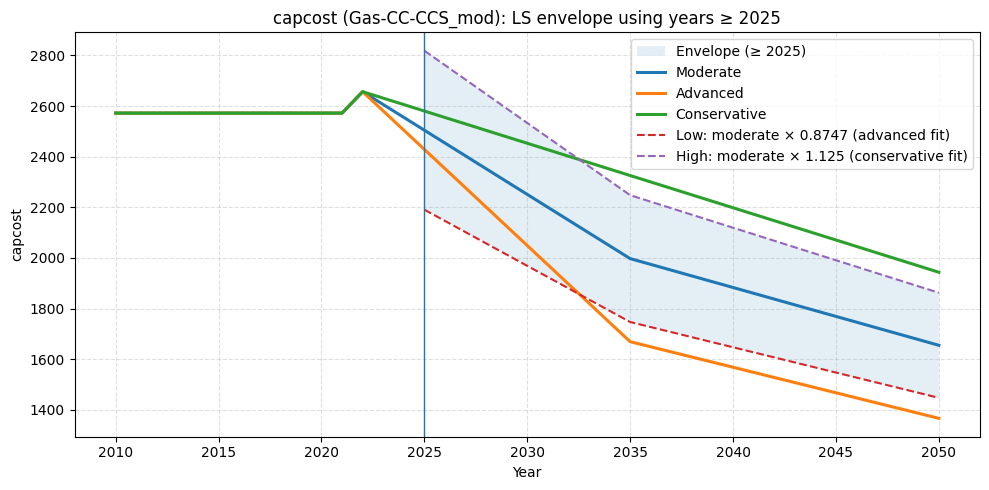

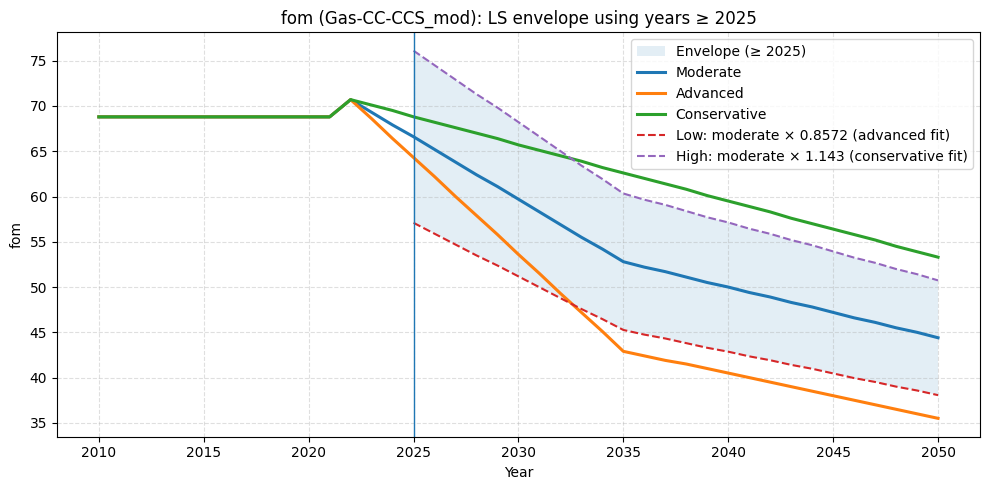

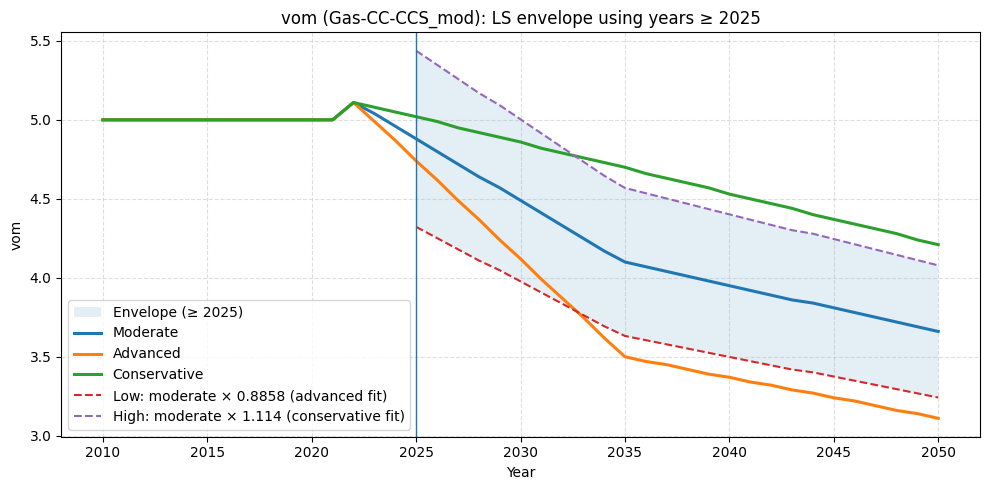

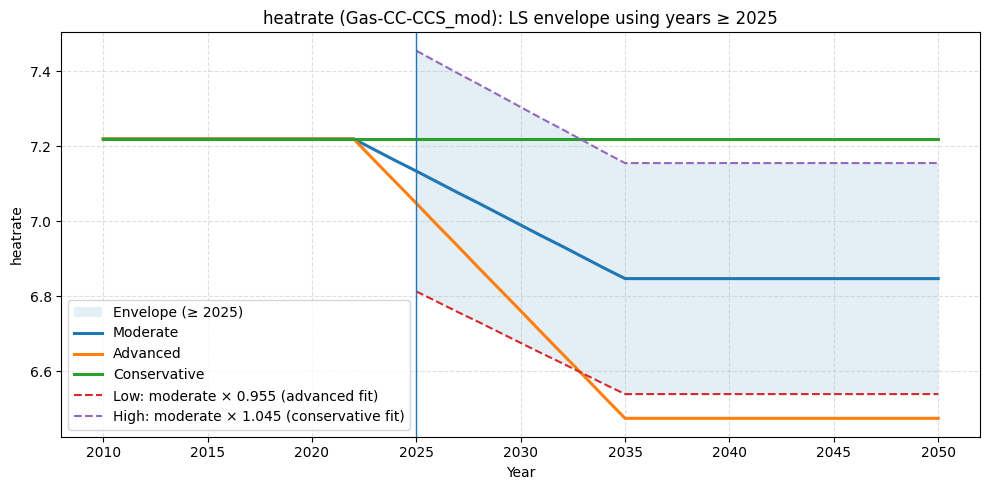

,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,capcost,0.874657,1.125349,0.874657,1.125349,advanced,conservative,26,2025,2050
1,fom,0.857239,1.142677,0.857239,1.142677,advanced,conservative,26,2025,2050
2,vom,0.885757,1.114353,0.885757,1.114353,advanced,conservative,26,2025,2050
3,heatrate,0.954979,1.045043,0.954979,1.045043,advanced,conservative,26,2025,2050


In [5]:
# Run + plot
results = []
for m in METRICS:
    results.append(plot_with_envelope(df, m, start_year=START_YEAR))

res = pd.DataFrame(results)
res

In [6]:
if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

Saved: gas_ccs_envelope_multipliers.csv


In [7]:
import numpy as np
import pandas as pd

# ----------------------------
# USER CONTROLS
# ----------------------------
N_SAMPLES = 2          # change as needed
RANDOM_SEED = 42        # reproducible
TECH_NAME_BASE = "Gas-CC-CCS"   # base tech name for sampled variants
BASE_SCENARIO = "moderate"      # baseline trajectory you scale (moderate)
OUT_CSV = "gas_ccs_ATB_2024_samples.csv"

METRICS = ["capcost", "fom", "vom", "heatrate"]

# ----------------------------
# 1) Build bounds dict from your envelope output
#    Assumes envelope_df has columns: ['metric','low_mult','high_mult', ...]
# ----------------------------
# safety: keep only the 4 metrics we want
env4 = res.loc[res["metric"].isin(METRICS)].copy()

missing = set(METRICS) - set(env4["metric"].unique())
if missing:
    raise ValueError(f"Envelope bounds missing for metrics: {missing}")

bounds = {
    row["metric"]: (float(row["low_mult"]), float(row["high_mult"]))
    for _, row in env4.iterrows()
}

# ----------------------------
# 2) Get the baseline (moderate) time series for Gas CCS
#    Assumes df_all has: scenario, t, metrics, and optionally i
# ----------------------------
base = df.loc[df["scenario"].str.lower().eq(BASE_SCENARIO)].copy()

# If your data has multiple techs in base, filter it explicitly:
# base = base.loc[base["i"].eq("Gas-CC-CCS_mod")].copy()

# Validate columns
required_cols = set(["t"] + METRICS)
missing_cols = required_cols - set(base.columns)
if missing_cols:
    raise ValueError(f"Baseline data missing columns: {missing_cols}")

# Ensure t is int
base["t"] = base["t"].astype(int)
base = base.sort_values("t").reset_index(drop=True)

# If baseline has an 'i' column, we will overwrite it; otherwise we will add it
if "i" not in base.columns:
    base["i"] = f"{TECH_NAME_BASE}_mod"

# Keep only the exact output schema + metrics
base_out = base[["i", "t"] + METRICS].copy()

# ----------------------------
# 3) Sample multipliers within [low_mult, high_mult] for each metric
# ----------------------------
rng = np.random.default_rng(RANDOM_SEED)

samples = []
for k in range(1, N_SAMPLES + 1):
    mults = {m: rng.uniform(bounds[m][0], bounds[m][1]) for m in METRICS}
    samples.append({"sample_id": k, **mults})

# Print samples in "list format"
samples_list = samples  # already a list of dicts
print(samples_list[:5])  # preview first 5 (optional)

# ----------------------------
# 4) Generate sampled trajectories (multiply moderate by sampled multipliers)
# ----------------------------
APPLY_FROM_YEAR = 2025

all_runs = []
for s in samples:
    df_s = base_out.copy()
    df_s["i"] = f"{TECH_NAME_BASE}_s{s['sample_id']:03d}"

    # Only multiply years >= 2025
    mask = df_s["t"] >= APPLY_FROM_YEAR
    for m in METRICS:
        df_s.loc[mask, m] = df_s.loc[mask, m].astype(float) * float(s[m])

    all_runs.append(df_s)

out_df = pd.concat(all_runs, ignore_index=True)


# Optional rounding (adjust as you like)
out_df["capcost"] = out_df["capcost"].round(2)
out_df["fom"]     = out_df["fom"].round(3)
out_df["vom"]     = out_df["vom"].round(4)
out_df["heatrate"]= out_df["heatrate"].round(3)

# Save in the exact GitHub-like format
out_df = out_df[["i", "t", "capcost", "fom", "vom", "heatrate"]]
out_df.to_csv(OUT_CSV, index=False)

print(f"Wrote {len(out_df):,} rows to: {OUT_CSV}")
print(out_df.head(10))

[{'sample_id': 1, 'capcost': 1.0686817261536454, 'fom': 0.9825117976258042, 'vom': 1.0820291964275743, 'heatrate': 1.0177868751396155}, {'sample_id': 2, 'capcost': 0.898266254987757, 'fom': 1.1357186322639725, 'vom': 1.059750595449187, 'heatrate': 1.0257751875538497}]
Wrote 82 rows to: gas_ccs_ATB_2024_samples.csv
                 i     t  capcost     fom     vom  heatrate
0  Gas-CC-CCS_s001  2010  2572.02  68.796  5.0004      7.22
1  Gas-CC-CCS_s001  2011  2572.02  68.796  5.0004      7.22
2  Gas-CC-CCS_s001  2012  2572.02  68.796  5.0004      7.22
3  Gas-CC-CCS_s001  2013  2572.02  68.796  5.0004      7.22
4  Gas-CC-CCS_s001  2014  2572.02  68.796  5.0004      7.22
5  Gas-CC-CCS_s001  2015  2572.02  68.796  5.0004      7.22
6  Gas-CC-CCS_s001  2016  2572.02  68.796  5.0004      7.22
7  Gas-CC-CCS_s001  2017  2572.02  68.796  5.0004      7.22
8  Gas-CC-CCS_s001  2018  2572.02  68.796  5.0004      7.22
9  Gas-CC-CCS_s001  2019  2572.02  68.796  5.0004      7.22


In [8]:
# sanity check: pre-2025 values unchanged for the first sample
test_id = 1
pre = out_df[(out_df["i"] == f"{TECH_NAME_BASE}_s{test_id:03d}") & (out_df["t"] < 2025)]
base_pre = base_out[base_out["t"] < 2025].copy()
assert np.allclose(pre["capcost"].values, base_pre["capcost"].values)



In [9]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
# Adjust if your nuclear file uses different units, but these match the common ReEDS plant_characteristics convention.
metric_units = {
    "capcost": r"\$/kW",
    "fom":     r"\$/kW-yr",
    "vom":     r"\$/MWh",
    "heatrate": r"\MMBtu/MWh ",
}




latex_rows = []

# Detect whether BOUNDS keys are (cls, metric) tuples or just metric strings
for key, (low_mult, high_mult) in bounds.items():
    if isinstance(key, tuple) and len(key) == 2:
        cls, metric = key
        parameter = rf"Gas-ccs -- {cls} -- {metric}"
    else:
        metric = key
        parameter = rf"Gas-ccs -- {metric}"

    unit = metric_units.get(metric, "unitless")

    # Upperbound then Lowerbound (your preferred order)
    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Gas-ccs ATB 2024}}
\label{{tab:Gas-ccs_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))

```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Gas-ccs ATB 2024}
\label{tab:Gas-ccs_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
Gas-ccs -- capcost & 1.1253 & 0.8747 & \$/kW (multiplier) \\
Gas-ccs -- fom & 1.1427 & 0.8572 & \$/kW-yr (multiplier) \\
Gas-ccs -- vom & 1.1144 & 0.8858 & \$/MWh (multiplier) \\
Gas-ccs -- heatrate & 1.0450 & 0.9550 & \MMBtu/MWh  (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# USER INPUTS (edit only these)
# ============================================================
START_YEAR = 2025

# Your GitHub raw links
MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv"
BOUNDS_URL        = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/all_multiplier_bounds.csv"

# Baseline ReEDS file (Gas-CCS ATB 2024 moderate/reference)
# If this exact URL differs in your repo/version, replace it here.
BASELINE_CANDIDATE_URLS = [
    "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas-ccs_ATB_2024_moderate.csv",
    "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas-ccs_ATB_2024_moderate.csv",
]

# Factor "parameter" names as they appear in *your* bounds/factor_map table
# (These must match the text used when you created all_multiplier_bounds.csv)
PARAM_STRINGS = {
    "capcost":   "Gas-ccs -- capcost",
    "fom":       "Gas-ccs -- fom",
    "vom":       "Gas-ccs -- vom",
    "heatrate":  "Gas-ccs -- heatrate",
}

# If the baseline file includes multiple tech rows in column "i",
# you can filter which rows get scaled using TECH_FILTER (optional).
# Leave as None to apply to ALL rows in the baseline file.
TECH_FILTER = None  # e.g., "Gas-CC-CCS" or "Gas-ccs" if needed

# Output folder
OUT_DIR = Path("gas_ccs_ATB_2024_morris_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Helpers
# ============================================================
def _read_csv_first_working(urls):
    last_err = None
    for u in urls:
        try:
            df = pd.read_csv(u)
            print(f"Loaded baseline from: {u}")
            return df, u
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Could not load baseline from any candidate URL.\nLast error: {last_err}")

def _safe_strip_hash(url: str) -> str:
    return url.split("#")[0]

def _resolve_factor_column(factor_map: pd.DataFrame, parameter_text: str) -> str:
    # factor_map must have at least: ['Parameter','factor'] (case-insensitive tolerant)
    cols = {c.lower(): c for c in factor_map.columns}
    pcol = cols.get("parameter", None)
    fcol = cols.get("factor", None)
    if pcol is None or fcol is None:
        raise ValueError(f"factor_map must contain columns Parameter and factor. Found: {list(factor_map.columns)}")

    hit = factor_map.loc[factor_map[pcol].astype(str).str.strip() == str(parameter_text).strip(), fcol]
    if hit.empty:
        # fallback: contains (in case of tiny formatting differences)
        hit = factor_map.loc[factor_map[pcol].astype(str).str.contains(str(parameter_text).strip(), regex=False, na=False), fcol]

    if hit.empty:
        raise ValueError(
            f"Could not find factor_map row for parameter '{parameter_text}'.\n"
            f"Fix: ensure your factor_map Parameter text matches exactly (or contains match)."
        )
    return str(hit.iloc[0])

def _get_bounds_for_parameter(bounds_df: pd.DataFrame, parameter_text: str):
    # bounds table columns should match your generated csv: Parameter, Upperbound, Lowerbound, Unit (names may vary)
    cols = {c.lower(): c for c in bounds_df.columns}
    pcol = cols.get("parameter", None)
    ucol = cols.get("upperbound", None) or cols.get("upper", None) or cols.get("high", None)
    lcol = cols.get("lowerbound", None) or cols.get("lower", None) or cols.get("low", None)

    if pcol is None or ucol is None or lcol is None:
        raise ValueError(f"Bounds file must include Parameter + Upperbound + Lowerbound. Found: {list(bounds_df.columns)}")

    hit = bounds_df.loc[bounds_df[pcol].astype(str).str.strip() == str(parameter_text).strip()]
    if hit.empty:
        hit = bounds_df.loc[bounds_df[pcol].astype(str).str.contains(str(parameter_text).strip(), regex=False, na=False)]

    if hit.empty:
        raise ValueError(f"Could not find bounds row for parameter '{parameter_text}'.")

    lo = float(hit.iloc[0][lcol])
    hi = float(hit.iloc[0][ucol])
    # ensure lo <= hi
    return (min(lo, hi), max(lo, hi))

def _design_is_normalized(x: pd.Series) -> bool:
    # Heuristic: all values inside [0,1] (with small tolerance)
    return (x.min() >= -1e-9) and (x.max() <= 1 + 1e-9)

def _convert_design_col_to_multiplier(x: pd.Series, lo: float, hi: float) -> pd.Series:
    # If x is normalized in [0,1], map to [lo,hi]; else assume already actual multiplier values
    if _design_is_normalized(x):
        return lo + x * (hi - lo)
    return x

# ============================================================
# 1) Load Morris inputs + bounds
# ============================================================
design = pd.read_csv(_safe_strip_hash(MORRIS_DESIGN_URL))
factor_map = pd.read_csv(_safe_strip_hash(FACTOR_MAP_URL))
bounds_df = pd.read_csv(_safe_strip_hash(BOUNDS_URL))

print("Loaded:")
print("  design shape:", design.shape)
print("  factor_map shape:", factor_map.shape)
print("  bounds shape:", bounds_df.shape)

# ============================================================
# 2) Resolve the Morris column names for Gas-CCS metrics
# ============================================================
design_cols = {}
bounds = {}
for metric, param_text in PARAM_STRINGS.items():
    col = _resolve_factor_column(factor_map, param_text)
    lo, hi = _get_bounds_for_parameter(bounds_df, param_text)
    design_cols[metric] = col
    bounds[metric] = (lo, hi)

print("\nResolved Morris columns + bounds:")
for m in PARAM_STRINGS:
    lo, hi = bounds[m]
    print(f"  {m:8s} -> {design_cols[m]}   bounds=[{lo:.6g}, {hi:.6g}]")

# ============================================================
# 3) Load baseline (ReEDS official) and preserve exact schema/order
# ============================================================
baseline_df, baseline_url_used = _read_csv_first_working(BASELINE_CANDIDATE_URLS)

# Preserve exact baseline columns & order (ReEDS-safe)
baseline_cols = list(baseline_df.columns)

# Basic required columns check
req_cols = {"t", "capcost", "fom", "vom", "heatrate"}
missing = req_cols - set(baseline_df.columns)
if missing:
    raise ValueError(f"Baseline missing required columns: {missing}. Found: {list(baseline_df.columns)}")

# Ensure numeric year
baseline_df["t"] = pd.to_numeric(baseline_df["t"], errors="coerce").astype(int)

# Optional tech filter if baseline contains multiple technologies
if TECH_FILTER is not None:
    if "i" not in baseline_df.columns:
        raise ValueError("TECH_FILTER was provided but baseline has no 'i' column.")
    tech_mask = baseline_df["i"].astype(str).str.contains(str(TECH_FILTER), regex=False, na=False)
    if tech_mask.sum() == 0:
        raise ValueError(f"TECH_FILTER='{TECH_FILTER}' matched 0 rows in baseline 'i' column.")
else:
    tech_mask = pd.Series(True, index=baseline_df.index)

# Mask for years >= START_YEAR
year_mask = baseline_df["t"] >= int(START_YEAR)

apply_mask = tech_mask & year_mask

# ============================================================
# 4) Build per-run multipliers from Morris design (normalized-safe)
# ============================================================
run_mults = pd.DataFrame({"run_id": np.arange(len(design), dtype=int)})

for metric in PARAM_STRINGS:
    col = design_cols[metric]
    lo, hi = bounds[metric]

    if col not in design.columns:
        raise ValueError(f"Design is missing column '{col}' for metric '{metric}'. Available: {list(design.columns)[:30]} ...")

    x = pd.to_numeric(design[col], errors="coerce")
    if x.isna().any():
        raise ValueError(f"Design column '{col}' has NaNs after numeric conversion.")

    run_mults[f"{metric}_mult"] = _convert_design_col_to_multiplier(x, lo, hi)

# ============================================================
# 5) Generate one ReEDS-format CSV per run
# ============================================================
generated_files = []
for _, r in run_mults.iterrows():
    rid = int(r["run_id"])
    out = baseline_df.copy()

    # Apply multipliers ONLY on apply_mask (years >= START_YEAR and optional tech filter)
    out.loc[apply_mask, "capcost"]   = out.loc[apply_mask, "capcost"].astype(float)   * float(r["capcost_mult"])
    out.loc[apply_mask, "fom"]       = out.loc[apply_mask, "fom"].astype(float)       * float(r["fom_mult"])
    out.loc[apply_mask, "vom"]       = out.loc[apply_mask, "vom"].astype(float)       * float(r["vom_mult"])
    out.loc[apply_mask, "heatrate"]  = out.loc[apply_mask, "heatrate"].astype(float)  * float(r["heatrate_mult"])

    # Enforce EXACT baseline ordering/schema (critical for ReEDS)
    out = out[baseline_cols]

    fp = OUT_DIR / f"gas-ccs_ATB_2024_morris_{rid:03d}.csv"
    out.to_csv(fp, index=False)
    generated_files.append(fp)

# Save multipliers table + manifest
run_mults.to_csv(OUT_DIR / "gas-ccs_ATB_2024_morris_multipliers.csv", index=False)

with open(OUT_DIR / "manifest.txt", "w") as f:
    f.write("Baseline used:\n")
    f.write(baseline_url_used + "\n\n")
    f.write("Generated files:\n")
    for fp in generated_files:
        f.write(str(fp) + "\n")

print(f"\nDone. Wrote {len(generated_files)} CSVs to: {OUT_DIR.resolve()}")
print(f"Saved multipliers table: {OUT_DIR / 'gas-ccs_ATB_2024_morris_multipliers.csv'}")
print(f"Saved manifest: {OUT_DIR / 'manifest.txt'}")
print("Example file:", generated_files[0])


Loaded:
  design shape: (200, 43)
  factor_map shape: (39, 5)
  bounds shape: (39, 4)

Resolved Morris columns + bounds:
  capcost  -> gas_ccs_capcost   bounds=[0.8747, 1.1253]
  fom      -> gas_ccs_fom   bounds=[0.8572, 1.1427]
  vom      -> gas_ccs_vom   bounds=[0.8858, 1.1144]
  heatrate -> gas_ccs_heatrate   bounds=[0.955, 1.045]
Loaded baseline from: https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas-ccs_ATB_2024_moderate.csv

Done. Wrote 200 CSVs to: /content/gas_ccs_ATB_2024_morris_outputs
Saved multipliers table: gas_ccs_ATB_2024_morris_outputs/gas-ccs_ATB_2024_morris_multipliers.csv
Saved manifest: gas_ccs_ATB_2024_morris_outputs/manifest.txt
Example file: gas_ccs_ATB_2024_morris_outputs/gas-ccs_ATB_2024_morris_000.csv


In [11]:
from pathlib import Path
import shutil

OUT_DIR = Path("gas_ccs_ATB_2024_morris_outputs")  # <- must match your script
zip_name = "gas_ccs_ATB_2024_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: gas_ccs_ATB_2024_morris_outputs.zip
